## Pascal VOC 2012数据集语义分割练习

- 下载数据集：https://www.kaggle.com/datasets/huanghanchina/pascal-voc-2012

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import random
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import ConcatDataset
from torch.utils.data import random_split
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### 加载数据

In [3]:
class VOCDataset(Dataset):
    """
    PASCAL VOC 2012 Semantic Segmentation Dataset
    image:
        RGB image

    mask:
        semantic segmentation label
        original label:
            0:
                background
            1-20:
                object classes
            255:
                ignore / void
        output:
            0-20:
                valid classes
            255:
                ignored in loss
    """

    def __init__(
        self,
        image_dir,
        mask_dir,
        split_file,
        transform=None
    ):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # 读取train/val ids
        with open(
            split_file,
            "r"
        ) as f:

            self.images = [
                x.strip()
                for x in f.readlines()
            ]

    def __len__(self):

        return len(self.images)

    def __getitem__(
        self,
        idx
    ):

        img_id = self.images[idx]

        # image path
        image_path = os.path.join(
            self.image_dir,
            img_id + ".jpg"
        )

        # mask path
        mask_path = os.path.join(
            self.mask_dir,
            img_id + ".png"
        )

        # read image
        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )

        # read mask
        mask = Image.open(
            mask_path
        )

        if self.transform:

            image, mask = self.transform(
                image,
                mask
            )

        return image, mask
    

class SegmentationTransform:
    """
    Semantic Segmentation Transform

    image:
        RGB image
        processing:
            resize
            random horizontal flip
            to tensor
            normalize

    mask:
        VOC semantic label
        original:
            0:
                background
            1-20:
                object classes
            255:
                ignore

        output:
            0-20:
                valid classes
            255:
                ignore
    """

    def __init__(
        self,
        size=256
    ):

        self.size = size

    def __call__(
        self,
        image,
        mask
    ):

        # resize image
        image = TF.resize(
            image,
            (self.size,self.size)
        )

        # resize mask
        # 必须NEAREST，否则类别被插值污染
        mask = TF.resize(
            mask,
            (self.size,self.size),
            interpolation=Image.NEAREST
        )

        # random flip
        if random.random() > 0.5:

            image = TF.hflip(
                image
            )
            mask = TF.hflip(
                mask
            )

        # image tensor
        image = TF.to_tensor(
            image
        )

        # normalize
        image = TF.normalize(
            image,
            mean=[
                0.485,
                0.456,
                0.406
            ],
            std=[
                0.229,
                0.224,
                0.225
            ]
        )

        # mask tensor
        mask = torch.tensor(
            np.array(mask),
            dtype=torch.long
        )
        # 注意:
        # VOC这里不要减1

        return image, mask

In [4]:
image_dir = "data/images"
mask_dir = "data/masks"
split_file = "data/splits/trainval.txt"

dataset = VOCDataset(
    image_dir,
    mask_dir,
    split_file,
    transform=None
)

In [5]:
print("数据数量:")
print(len(dataset))

image, mask = dataset[100]
print("----------------")
print("image shape:")
print(image.size)

print("mask shape:")
print(mask.size)

print("mask unique:")
print(np.unique(np.array(mask)))

数据数量:
2913
----------------
image shape:
(500, 375)
mask shape:
(500, 375)
mask unique:
[  0   9  11 255]


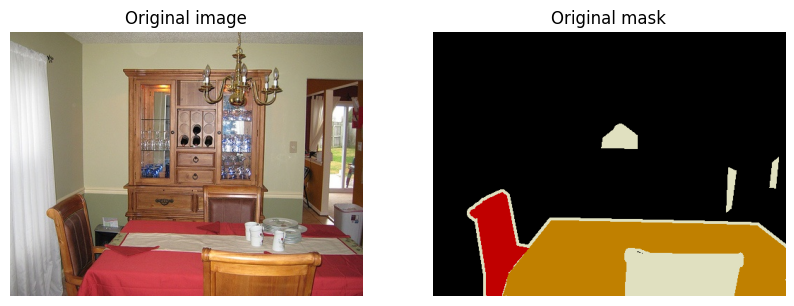

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Original mask")
plt.axis("off")

plt.show()

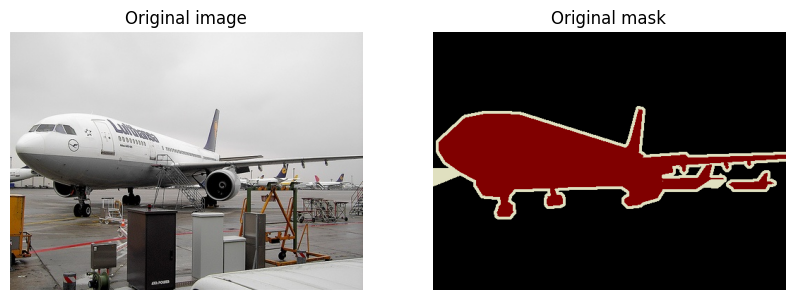

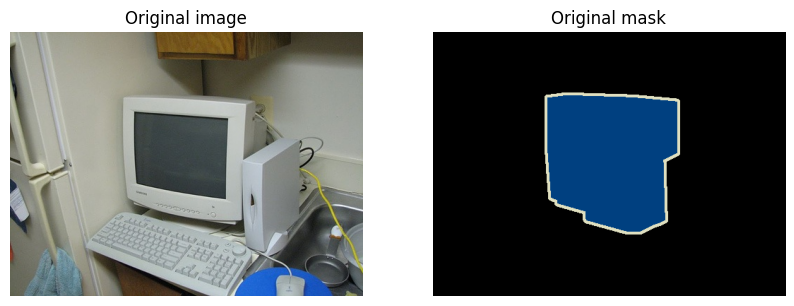

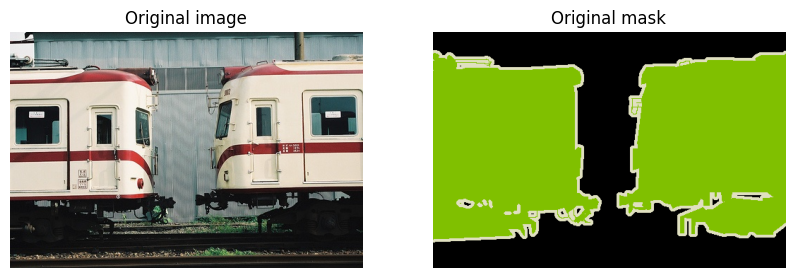

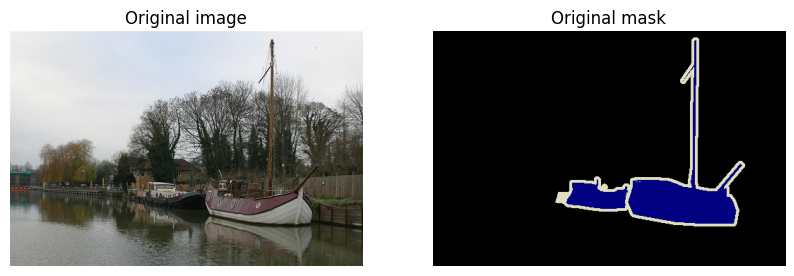

In [7]:
for i in range(1, 5):
    image, mask = dataset[i]

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask)
    plt.title("Original mask")
    plt.axis("off")

    plt.show()

### 数据处理

#### 增强

In [8]:
transform = SegmentationTransform(  # 数据增强
    size=256
)

train_split = "data/splits/train.txt"
val_split = "data/splits/val.txt"

In [9]:
train_dataset = VOCDataset(
    image_dir,
    mask_dir,
    train_split,
    transform
)
val_dataset = VOCDataset(
    image_dir,
    mask_dir,
    val_split,
    transform
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].


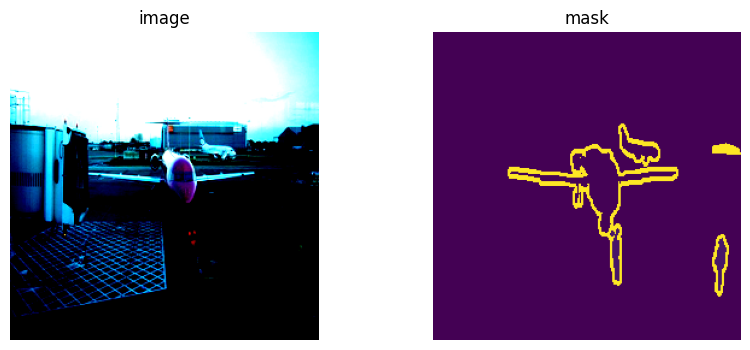

In [10]:
image, mask = train_dataset[0]

plt.figure(figsize=(10,4)) 

plt.subplot(1,2,1) 
plt.imshow( image.permute(1,2,0) ) 
plt.title("image") 
plt.axis("off") 

plt.subplot(1,2,2) 
plt.imshow( mask ) 
plt.title("mask") 
plt.axis("off") 

plt.show()

In [11]:
print("train_dataset:")
print(len(train_dataset))

image, mask = train_dataset[0]
print("----------------")
print("image shape:")
print(image.shape)

print("mask shape:")
print(mask.shape)

print("mask unique:")
print(mask.unique())

train_dataset:
1464
----------------
image shape:
torch.Size([3, 256, 256])
mask shape:
torch.Size([256, 256])
mask unique:
tensor([  0,   1,  15, 255])


In [12]:
print("val_dataset:")
print(len(val_dataset))

image, mask = val_dataset[0]
print("----------------")
print("image shape:")
print(image.shape)

print("mask shape:")
print(mask.shape)

print("mask unique:")
print(mask.unique())

val_dataset:
1449
----------------
image shape:
torch.Size([3, 256, 256])
mask shape:
torch.Size([256, 256])
mask unique:
tensor([  0,   1, 255])


#### 创建DataLoader

In [13]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [14]:
images, masks = next(iter(train_dataloader))

print("train_dataloader:")
print(len(train_dataloader))
print("images:")
print(images.shape)

print("masks:")
print(masks.shape)

print("mask classes:")
print(masks.unique())

train_dataloader:
183
images:
torch.Size([8, 3, 256, 256])
masks:
torch.Size([8, 256, 256])
mask classes:
tensor([  0,   1,   4,   6,   7,  10,  14,  15,  16, 255])


In [15]:
images, masks = next(iter(val_dataloader))

print("val_dataloader:")
print(len(val_dataloader))
print("images:")
print(images.shape)

print("masks:")
print(masks.shape)

print("mask classes:")
print(masks.unique())

val_dataloader:
182
images:
torch.Size([8, 3, 256, 256])
masks:
torch.Size([8, 256, 256])
mask classes:
tensor([  0,   1,   2,   4,  15,  17,  19,  20, 255])


In [16]:
def denormalize(img):

    mean = torch.tensor(
        [0.485,0.456,0.406]
    )

    std = torch.tensor(
        [0.229,0.224,0.225]
    )

    img = img.clone()


    for t,m,s in zip(
        img,
        mean,
        std
    ):
        t.mul_(s).add_(m)


    return img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].


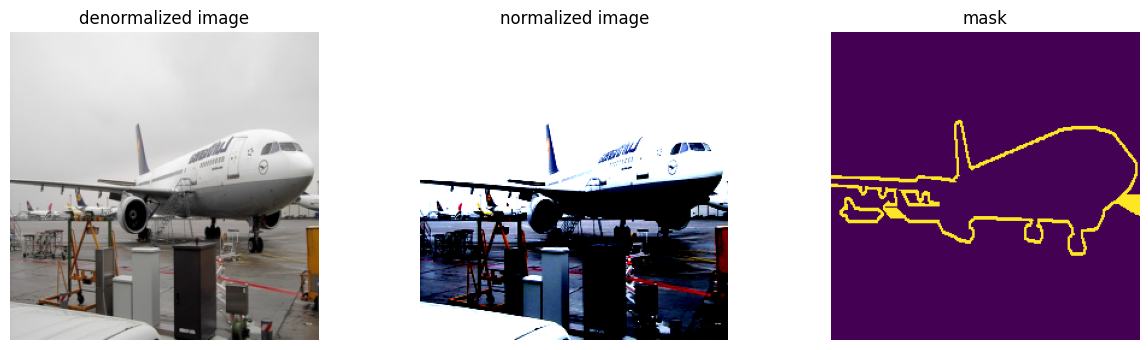

In [17]:
img = images[0]
mask = masks[0]
img_show = denormalize(images[0])

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img_show.permute(1,2,0))
plt.title("denormalized image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    img.permute(1,2,0)
)
plt.title("normalized image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")

plt.show()

### 构建U-Net模型（Encoder + Decoder + Skip Connection）

#### U-Net核心层DoubleConv

In [18]:
class DoubleConv(nn.Module):

    """
    Basic convolution block

    Conv2d
    BatchNorm
    ReLU
    Conv2d
    BatchNorm
    ReLU
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.ReLU(inplace=True)

        )

    def forward(self,x):

        return self.conv(x)

#### Down采样模块

In [19]:
class Down(nn.Module):

    """
    Downsampling block

    MaxPool
    +
    DoubleConv
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(
                in_channels,
                out_channels
            )
        )

    def forward(self,x):

        return self.down(x)

#### Up采样模块

In [20]:
class Up(nn.Module):

    """
    Upsampling block

    Transposed convolution
    +
    skip connection
    """

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels//2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(
        self,
        x1,
        x2
    ):

        # decoder feature
        x1=self.up(x1)

        # concat skip connection
        x=torch.cat(
            [x2,x1],
            dim=1
        )

        return self.conv(x)

#### U-Net主体

In [21]:
class UNet(nn.Module):

    """
    U-Net semantic segmentation model

    Input:
        RGB image

    Output:
        Pixel-wise class prediction
    """

    def __init__(
        self,
        num_classes=3
    ):

        super().__init__()

        self.inc = DoubleConv(
            3,
            32
        )
        self.down1 = Down(
            32,
            64
        )
        self.down2 = Down(
            64,
            128
        )

        self.down3 = Down(
            128,
            256
        )
        self.up1 = Up(
            256,
            128
        )
        self.up2 = Up(
            128,
            64
        )
        self.up3 = Up(
            64,
            32
        )

        self.out = nn.Conv2d(
            32,
            num_classes,
            1
        )


    def forward(self,x):

        x1=self.inc(x)
        x2=self.down1(x1)
        x3=self.down2(x2)
        x4=self.down3(x3)

        x=self.up1(
            x4,
            x3
        )
        x=self.up2(
            x,
            x2
        )
        x=self.up3(
            x,
            x1
        )

        output=self.out(x)

        return output

#### 测试

In [22]:
model=UNet(
    num_classes=21
).to(device)

x=torch.randn(
    2,
    3,
    256,
    256
).to(device)

y=model(x)
print(y.shape)

torch.Size([2, 21, 256, 256])


In [23]:
images, masks = next(iter(train_dataloader))
images = images.to(device)
masks = masks.to(device)

print(images.device)
print(masks.device)

print(next(model.parameters()).device)

cuda:0
cuda:0
cuda:0


### 模型训练

#### 评价指标

In [24]:
def confusion_matrix(
    preds,
    masks,
    num_classes=21,
    ignore_index=255
):

    preds = preds.view(-1)

    masks = masks.view(-1)


    valid = (
        masks != ignore_index
    )


    preds = preds[valid]
    masks = masks[valid]


    hist = torch.bincount(
        num_classes * masks + preds,
        minlength=num_classes ** 2
    )


    return hist.reshape(
        num_classes,
        num_classes
    )


def compute_miou(
    confusion_matrix
):

    intersection = torch.diag(
        confusion_matrix
    )

    union = (
        confusion_matrix.sum(1)
        +
        confusion_matrix.sum(0)
        -
        intersection
    )

    iou = (
        intersection /
        union.clamp(min=1)
    )
    return iou.mean().item()


def pixel_accuracy(
    outputs,
    masks
):

    preds = torch.argmax(
        outputs,
        dim=1
    )

    valid = (
        masks != 255  # 不参与计算的像素
    )

    correct = (
        preds[valid] == masks[valid]
    ).sum().item()

    total = valid.sum().item()

    return correct / total

#### 训练函数

In [25]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    total_acc = 0
    total_iou = 0


    for images,masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        acc = pixel_accuracy(
            outputs,
            masks
        )

        iou = compute_miou(
            confusion_matrix(
                torch.argmax(outputs, dim=1),
                masks,
                num_classes=21
            ).to(device)
        )

        total_loss += loss.item()
        total_acc += acc
        total_iou += iou

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_iou / len(loader)
    )

#### 验证函数

In [26]:




def validate(
    model,
    loader,
    criterion,
    device
):

    """
    Validation

    Return:
        avg_loss
        avg_accuracy
    """

    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    running_iou = 0.0

    with torch.no_grad():


        for images, masks in loader:

            images = images.to(
                device,
                non_blocking=True
            )
            masks = masks.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            acc = pixel_accuracy(
                outputs,
                masks
            )

            iou = compute_miou(
                confusion_matrix(
                    torch.argmax(outputs, dim=1),
                    masks,
                    num_classes=21
                ).to(device)
            )

            running_loss += loss.item()
            running_acc += acc
            running_iou += iou


    epoch_loss = (
        running_loss /
        len(loader)
    )
    epoch_acc = (
        running_acc /
        len(loader)
    )
    epoch_iou = (
        running_iou /
        len(loader)
    )

    return epoch_loss, epoch_acc, epoch_iou

#### 训练

In [27]:
# 合并数据集并8/2分割
full_dataset = ConcatDataset([
    train_dataset,
    val_dataset
])

# 计算划分数量
total_size = len(full_dataset)
train_size = int(total_size * 0.8)
val_size = total_size - train_size

# 随机划分
train_dataset_new, val_dataset_new = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # 保证每次划分一致
)

In [28]:
# DataLoader
train_dataloader = DataLoader(
    train_dataset_new,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_dataloader = DataLoader(
    val_dataset_new,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [29]:
# model
model = UNet(
    num_classes=21
)
model = model.to(device)

# loss
criterion = nn.CrossEntropyLoss(ignore_index=255)  # VOC的特殊标签

# optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [30]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []
train_ious = []
val_ious = []

epochs = 20
for epoch in range(epochs):

    train_loss, train_acc, train_iou = train_one_epoch(
        model,
        train_dataloader,
        criterion,
        optimizer,
        device,
    )

    val_loss, val_acc, val_iou = validate(
        model,
        val_dataloader,
        criterion,
        device
    )

    print(
        f"""
        Epoch [{epoch+1}/{epochs}]
        Train | Loss:{train_loss:.4f} Acc:{train_acc:.4f} mIoU:{train_iou:.4f}
        Validation | Loss:{val_loss:.4f} Acc:{val_acc:.4f} mIoU:{val_iou:.4f}
        """
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_ious.append(train_iou)
    val_ious.append(val_iou)


        Epoch [1/20]
        Train | Loss:2.9034 Acc:0.2731 mIoU:0.0215
        Validation | Loss:2.7538 Acc:0.4547 mIoU:0.0309
        

        Epoch [2/20]
        Train | Loss:2.5169 Acc:0.4871 mIoU:0.0344
        Validation | Loss:2.5409 Acc:0.4726 mIoU:0.0338
        

        Epoch [3/20]
        Train | Loss:2.2626 Acc:0.5271 mIoU:0.0354
        Validation | Loss:2.1587 Acc:0.5624 mIoU:0.0369
        

        Epoch [4/20]
        Train | Loss:2.0444 Acc:0.5595 mIoU:0.0362
        Validation | Loss:1.9492 Acc:0.6098 mIoU:0.0391
        

        Epoch [5/20]
        Train | Loss:1.8484 Acc:0.6067 mIoU:0.0382
        Validation | Loss:1.7790 Acc:0.6262 mIoU:0.0397
        

        Epoch [6/20]
        Train | Loss:1.6865 Acc:0.6468 mIoU:0.0399
        Validation | Loss:1.6818 Acc:0.6723 mIoU:0.0419
        

        Epoch [7/20]
        Train | Loss:1.5528 Acc:0.6937 mIoU:0.0416
        Validation | Loss:1.5647 Acc:0.7114 mIoU:0.0422
        

        Epoch [8/20]
        Trai

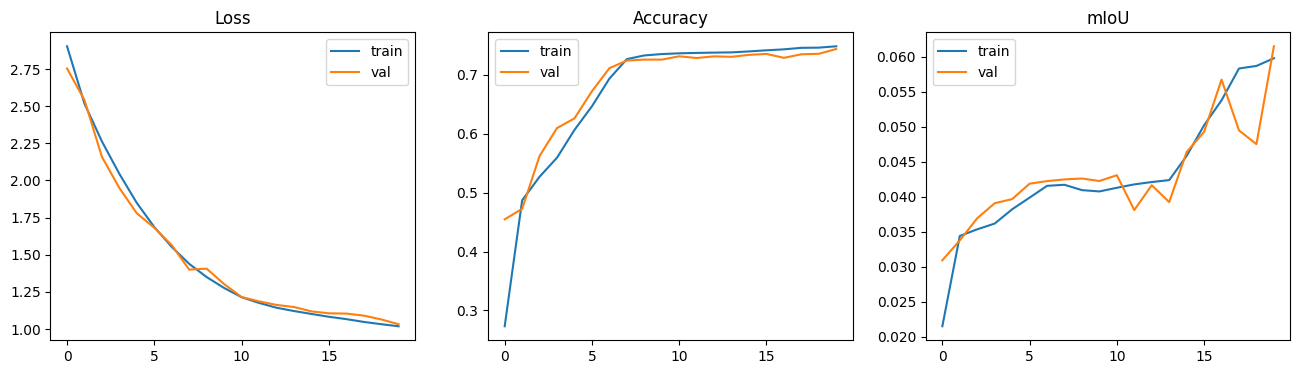

In [31]:
plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.plot(
    train_losses,
    label="train"
)
plt.plot(
    val_losses,
    label="val"
)
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(
    train_accs,
    label="train"
)
plt.plot(
    val_accs,
    label="val"
)
plt.title("Accuracy")
plt.legend()

plt.subplot(1,3,3)
plt.plot(
    train_ious,
    label="train"
)
plt.plot(
    val_ious,
    label="val"
)
plt.title("mIoU")
plt.legend()

plt.show()

### 推理

In [32]:
model.eval()

UNet(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (down): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [45]:
def visualization(image, mask, pred):
    """
    Visualize the image, ground truth mask, and predicted mask

    Args:
        image: Tensor of shape (C, H, W)
        mask: Tensor of shape (H, W)
        pred: Tensor of shape (H, W)
    """

    # Denormalize the image for visualization
    image = denormalize(image).permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.cpu().numpy())
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred.cpu().numpy())
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

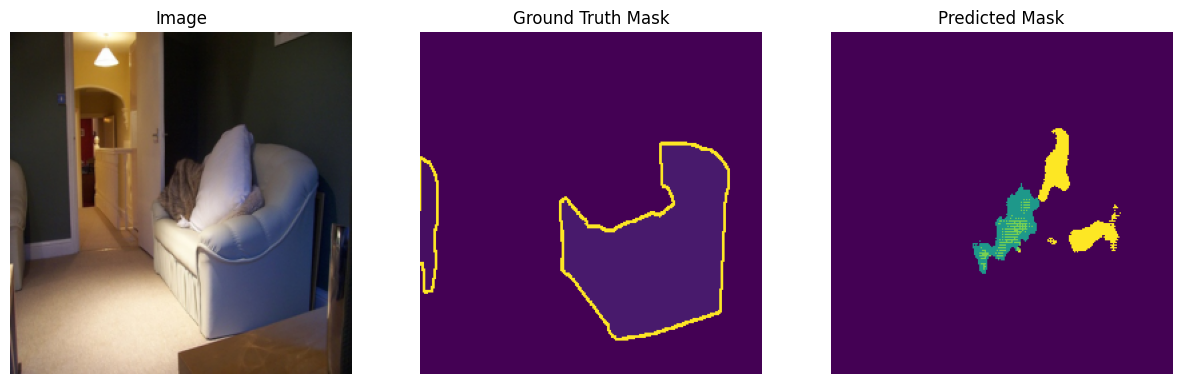

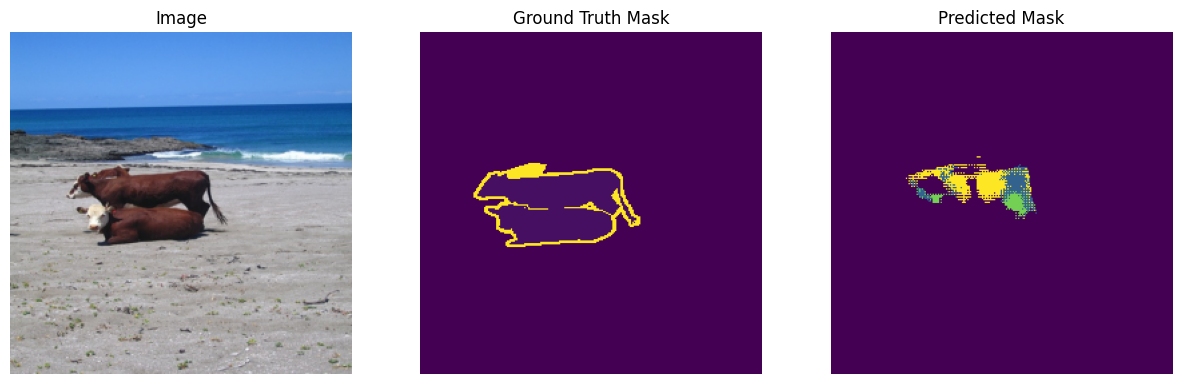

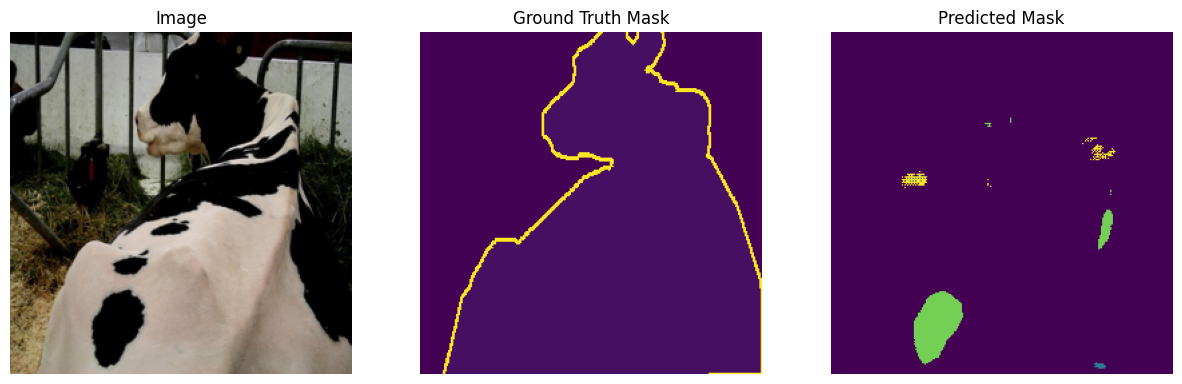

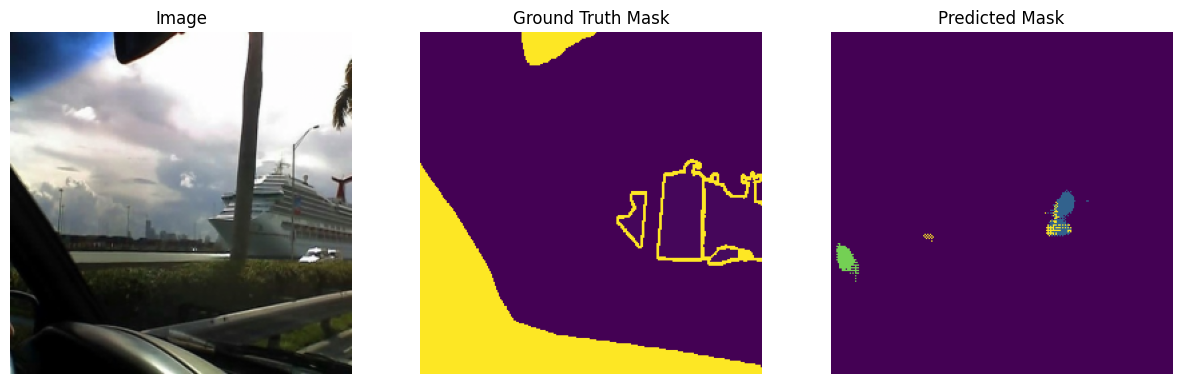

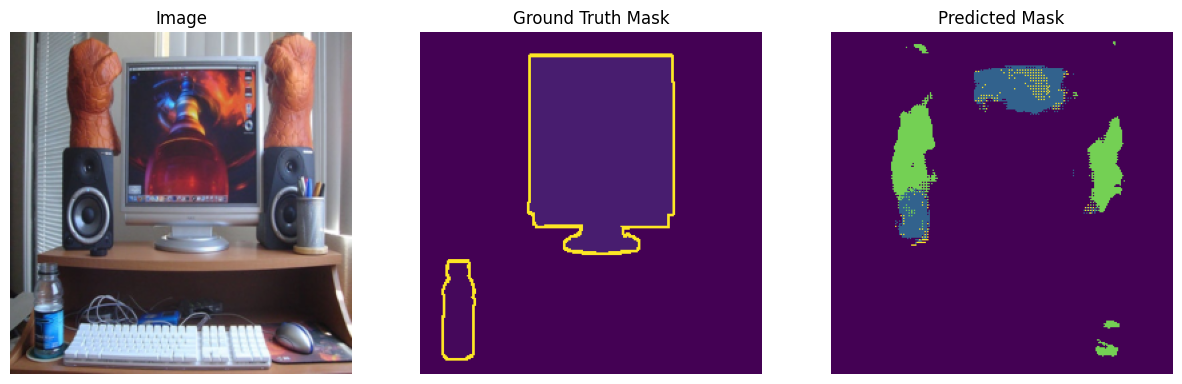

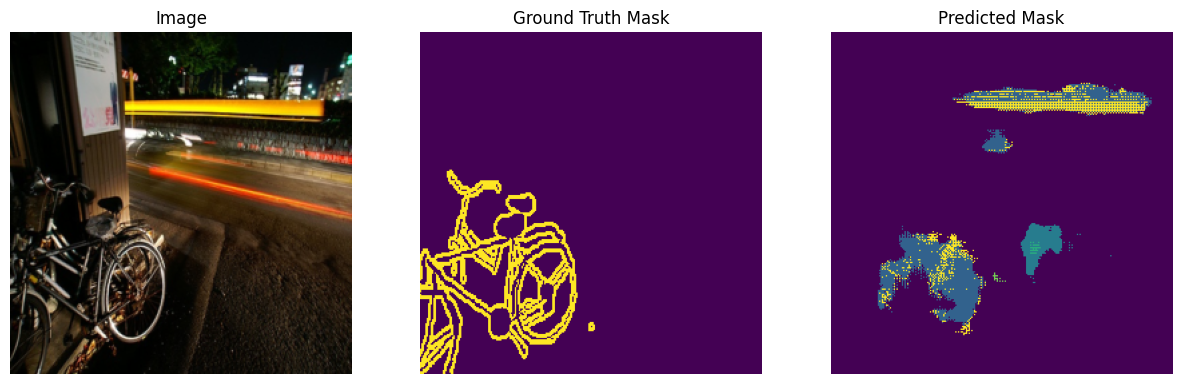

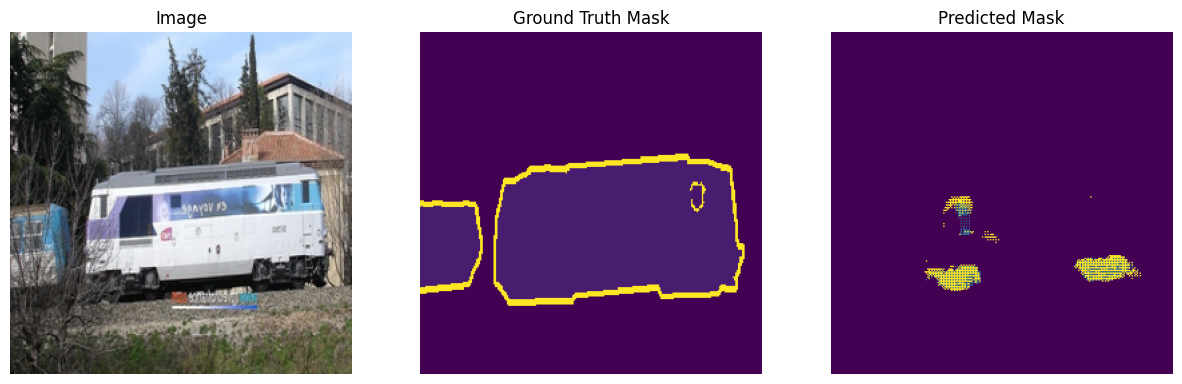

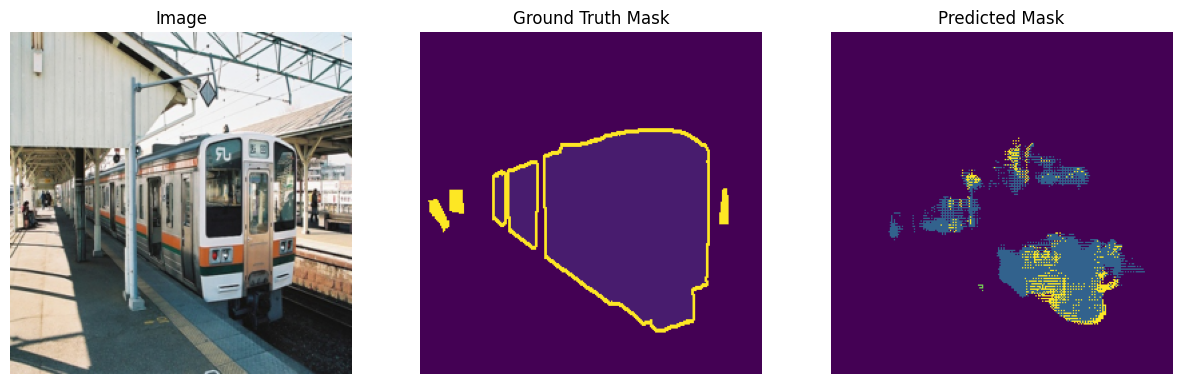

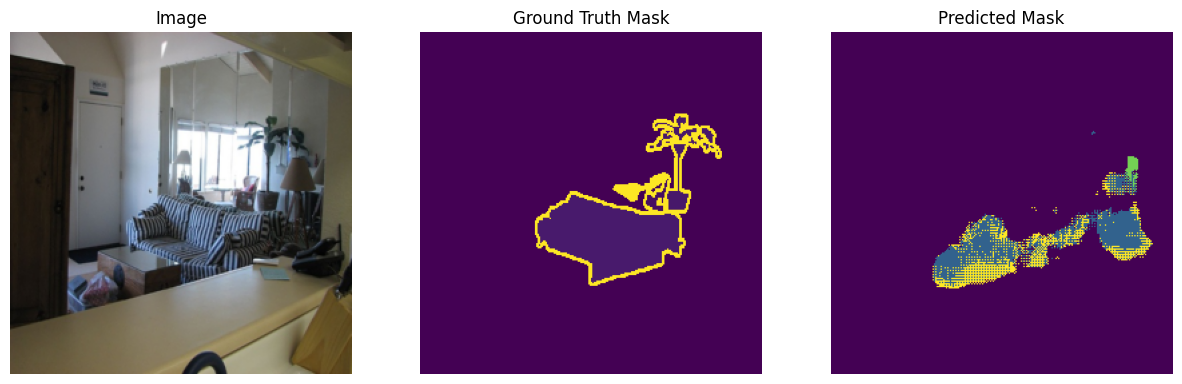

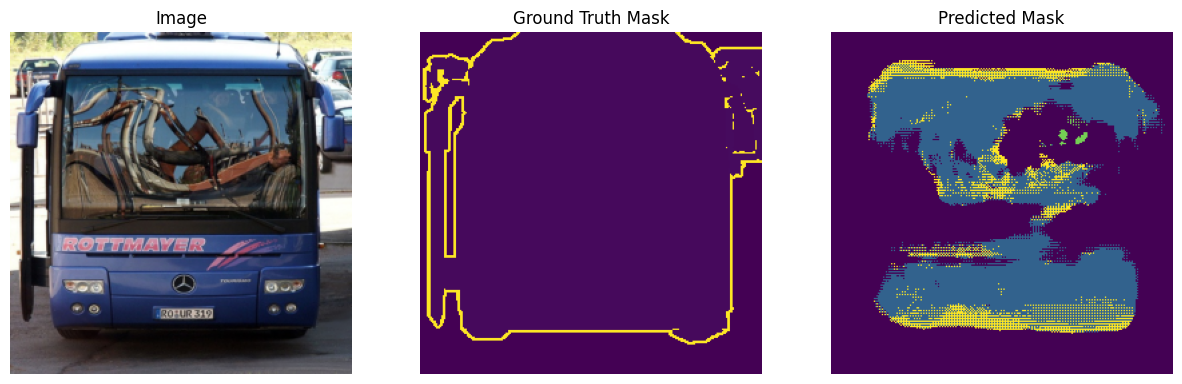

In [47]:
for i in range(10,20):
    image, mask = val_dataset[i]

    # 保存真实尺寸
    input_image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(
            input_image
        )

    # 分类结果
    pred = torch.argmax(
        output,
        dim=1
    )
    pred = pred.squeeze(0)

    visualization(image, mask, pred)